In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr

In [4]:
data = pd.DataFrame(columns=["p", "T", "d", "d_top", "n"])

for i in range(1, 31):
    with open(f"welltests//W{i}_welltest.txt") as f:
        #read all lines from file "f" 
        lines = f.readlines()
        #temperature is on the 6th line
        T = float(lines[6][-9:][0:8])
        p = float(lines[5][-9:][0:8])
    
    log_i = np.loadtxt(f"welllogs//W{i}_welllogs.txt", skiprows=4)
    d = log_i[-1, 0] - log_i[0, 0]
    d_top = log_i[0, 0]
    n = np.mean(log_i[:, 1])
    
    #loc => creates new row => now there are from 0 to 29 rows 
    data.loc[i-1] = [p, T, d, d_top, n]

data.head()

,p,T,d,d_top,n
0,190.657,339.194,82.15,1807.00,0.161835
1,204.845,341.336,126.02,1922.14,0.189198
2,198.011,342.076,107.07,1953.64,0.163787
3,210.697,346.547,181.79,2102.64,0.183000
4,211.411,341.225,122.67,1917.34,0.177893


# Check correlations

In the following code cell all correlations are found for all variables. Also a nice table is displayed with all correlations.

In [45]:
          
'-----------------------p-----------------------'
cor_p_T = pearsonr(data['p'],data['T'])
cor_p_d = pearsonr(data['p'],data['d'])
cor_p_d_top = pearsonr(data['p'],data['d_top'])
cor_p_n = pearsonr(data['p'],data['n'])

'-----------------------T-----------------------'
cor_T_d = pearsonr(data['T'],data['d'])
cor_T_d_top = pearsonr(data['T'],data['d_top'])
cor_T_n = pearsonr(data['T'],data['n'])


'-----------------------d-----------------------'
cor_d_d_top = pearsonr(data['d'],data['d_top'])
cor_d_n = pearsonr(data['d'],data['n'])

'-----------------------d_top-----------------------'
cor_d_top_n = pearsonr(data['d_top'],data['n'])

ind = ['p', 'T', 'd', 'd_top', 'n']
#create a mtrix
A = np.array([
    ['-',  round(cor_p_T[0],4), round(cor_p_d[0],4), round(cor_p_d_top[0],4), round(cor_p_n[0],4)],
    [round(cor_p_T[0],4), '-', round(cor_T_d[0],4), round(cor_T_d_top[0],4), round(cor_T_n[0],4)],
    [round(cor_p_d[0],4), round(cor_T_d[0],4), '-', round(cor_d_d_top[0],4), round(cor_d_n[0],4)],
    [round(cor_p_d_top[0],4), round(cor_T_d_top[0],4), round(cor_d_d_top[0],4), '-', round(cor_d_top_n[0],4)],
    [round(cor_p_n[0],4), round(cor_T_n[0],4), round(cor_d_n[0],4), round(cor_d_top_n[0],4), '-'],
])

a = pd.DataFrame(A, index=ind, columns=ind)
display(a)

,p,T,d,d_top,n
p,-,0.8128,0.1577,0.8429,0.5136
T,0.8128,-,-0.0828,0.9683,0.518
d,0.1577,-0.0828,-,-0.0397,0.1881
d_top,0.8429,0.9683,-0.0397,-,0.5659
n,0.5136,0.518,0.1881,0.5659,-


We are only interested in the variables which are defenitely correlating. In this case we take all r-values above 0.6 and below -0.6. In the code below we will plot these variables against eachother.

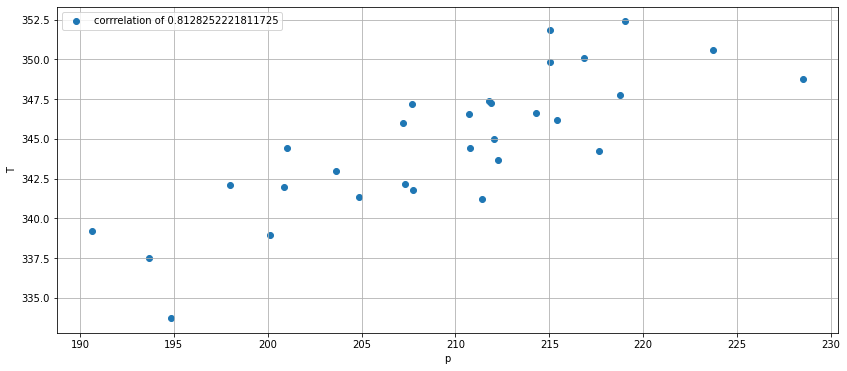

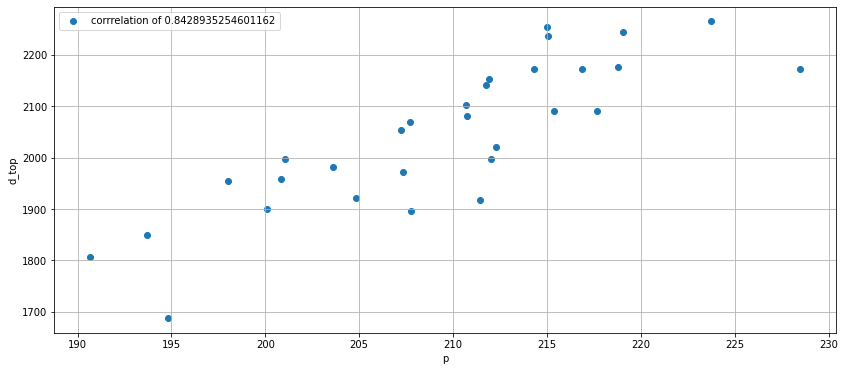

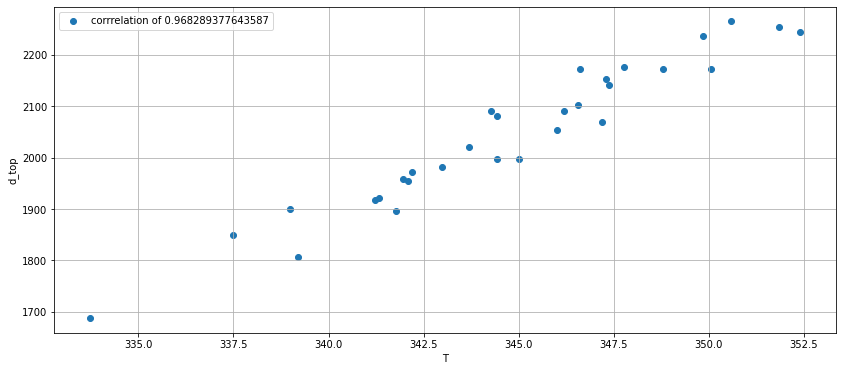

In [46]:
cor = []
for i in data.columns:
    for j in data.columns:
        r = pearsonr(data[i], data[j])[0]
        if i != j and r not in cor and (r > 0.6 or  r < -0.6):
            cor.append(pearsonr(data[i], data[j])[0])
            plt.figure(figsize=(14, 6))
            plt.scatter(data[i], data[j], label=f'corrrelation of {r}')
            plt.legend()
            plt.xlabel(i)
            plt.ylabel(j)
            plt.grid()

As one can see, the strong correlations between different variables are those between:

- temperature and pressure

- depth of the top of the well and the pressure

- depth of the top of the well and the temperature